# Diffusion Model (DDPM) — Butterfly Image Generation

Class-conditional DDPM to generate synthetic butterfly images for data augmentation.

**Structure:**
1. Setup & Imports
2. Data Loading
3. Training Function
4. Baseline DDPM
5. Grid Search
6. Final Training
7. Generate Augmented Dataset
8. Retrain Baseline CNN + Evaluate
9. Metrics & Comparison

## 1. Setup & Imports

In [1]:
import torch
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA disponível:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA disponível: True
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
CUDA version: 12.8


In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch", "torchvision",
    "--index-url", "https://download.pytorch.org/whl/cu128"
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "numpy",
    "pandas",
    "matplotlib",
    "tqdm",
    "pillow",
    "scikit-learn",
    "scikit-image",
    "kagglehub",
    "torchmetrics[image]",
    "ipykernel"
])

0

In [3]:
import os, sys, json, random, itertools, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as T
import torchvision.utils as vutils
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from skimage.metrics import structural_similarity as ssim_metric

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchmetrics[image]', '-q'])
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore

import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from utils import get_splits, get_class_mapping, GLOBAL_SEED
from diffusion import GaussianDiffusion, UNet, linear_beta_schedule, cosine_beta_schedule
print('OK')

Device: cuda
OK


## 2. Data Loading

In [4]:
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename','label']]
train_df, val_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Classes: {NUM_CLASSES}')

IMAGE_SIZE = 64
BATCH_SIZE = 32

diff_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])
diff_transform_val = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

train_ds = ButterflyDataset(df=train_df, img_dir=train_dir, transform=diff_transform)
val_ds   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=diff_transform_val)
train_ld = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_ld   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def denorm(t): return (t * 0.5 + 0.5).clamp(0,1)
print('Data loaders ready.')

Train: 4159 | Val: 1040 | Classes: 75
Data loaders ready.


## 3. Training Function

In [12]:
def train_ddpm(timesteps=500, schedule='cosine', base_ch=64, lr=1e-4,
               epochs=60, patience=8, verbose=True,
               ckpt_path=None, save_every=10):
    """Train a class-conditional DDPM on 64x64 butterfly images."""
    betas = cosine_beta_schedule(timesteps) if schedule == 'cosine' else linear_beta_schedule(timesteps)
    diffusion = GaussianDiffusion(betas).to(device)
    model     = UNet(base_ch=base_ch, num_classes=NUM_CLASSES).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/10)

    best_loss, no_imp, best_state = float('inf'), 0, None
    history = []

    epoch_iter = tqdm(range(epochs), desc='DDPM epochs', disable=not verbose)

    for epoch in epoch_iter:
        model.train()
        ep_loss = 0

        train_iter = tqdm(
            train_ld,
            desc=f'Epoch {epoch+1}/{epochs} train',
            leave=False,
            disable=not verbose
        )

        for batch_idx, (imgs, labels) in enumerate(train_iter, start=1):
            imgs = imgs.to(device)
            labels = labels.to(device)

            t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
            loss = diffusion.p_losses(model, imgs, t, class_labels=labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            ep_loss += loss.item()
            train_iter.set_postfix(loss=f'{ep_loss / batch_idx:.4f}')

        ep_loss /= len(train_ld)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            val_iter = tqdm(
                val_ld,
                desc=f'Epoch {epoch+1}/{epochs} val',
                leave=False,
                disable=not verbose
            )

            for batch_idx, (imgs, labels) in enumerate(val_iter, start=1):
                imgs = imgs.to(device)
                labels = labels.to(device)

                t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
                loss = diffusion.p_losses(model, imgs, t, class_labels=labels)

                val_loss += loss.item()
                val_iter.set_postfix(loss=f'{val_loss / batch_idx:.4f}')

        val_loss /= len(val_ld)
        scheduler.step()

        history.append({
            'epoch': epoch + 1,
            'train_loss': ep_loss,
            'val_loss': val_loss
        })

        should_stop = False

        if val_loss < best_loss:
            best_loss = val_loss
            no_imp = 0
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            no_imp += 1
            should_stop = no_imp >= patience

        if verbose:
            epoch_iter.set_postfix(
                train=f'{ep_loss:.4f}',
                val=f'{val_loss:.4f}',
                best=f'{best_loss:.4f}'
            )

            print(
                f'Epoch {epoch+1:3d}/{epochs} | '
                f'train={ep_loss:.4f} | '
                f'val={val_loss:.4f} | '
                f'best={best_loss:.4f} | '
                f'no_imp={no_imp}/{patience}'
            )

        if should_stop:
            if verbose:
                print(f'[EarlyStopping] Epoch {epoch+1}/{epochs}')
            break

    model.load_state_dict(best_state)
    model.to(device)

    return model, diffusion, best_loss, history

## 4. Baseline DDPM (default hypers)

In [6]:
print('Training baseline DDPM (T=500, cosine, base_ch=64, lr=1e-4, 60 epochs)...')
model_base, diff_base, base_val_loss, base_hist = train_ddpm(
    timesteps=500, schedule='cosine', base_ch=64, lr=1e-4, epochs=60, patience=8)
print(f'Baseline DDPM best val loss: {base_val_loss:.4f}')

Training baseline DDPM (T=500, cosine, base_ch=64, lr=1e-4, 60 epochs)...


DDPM epochs:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1/60 train:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 1/60 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch   1/60 | train=0.3341 | val=0.1324 | best=0.1324 | no_imp=0/8


...

Epoch 20/60 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch  20/60 | train=0.0642 | val=0.0607 | best=0.0591 | no_imp=7/8


Epoch 21/60 train:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 21/60 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch  21/60 | train=0.0619 | val=0.0630 | best=0.0591 | no_imp=8/8
[EarlyStopping] Epoch 21/60
Baseline DDPM best val loss: 0.0591


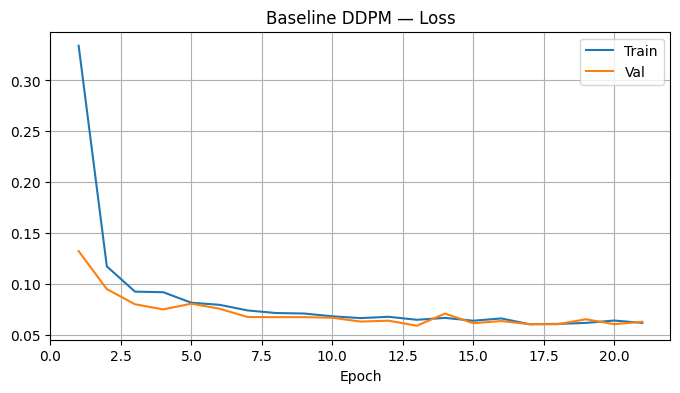

In [7]:
hist_df = pd.DataFrame(base_hist)
plt.figure(figsize=(8,4))
plt.plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
plt.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val')
plt.title('Baseline DDPM — Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/ddpm_baseline_loss.png', dpi=150); plt.show()

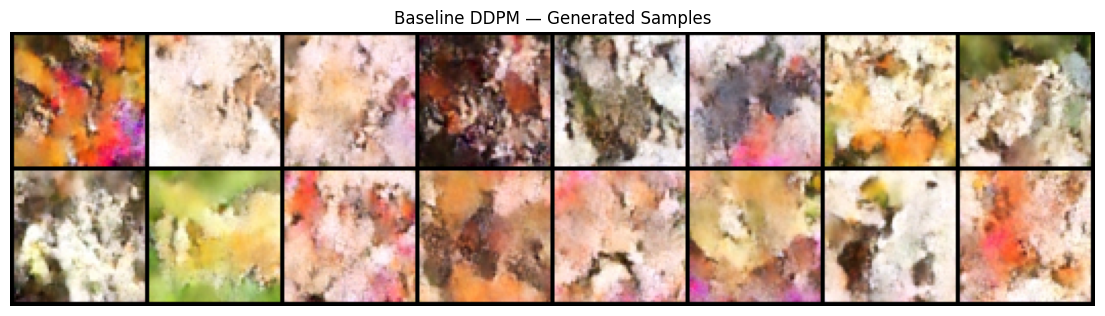

In [8]:
# Preview: generate 16 images (one per class, first 16 classes)
model_base.eval()
preview_labels = torch.arange(min(16, NUM_CLASSES), device=device)
with torch.no_grad():
    samples = diff_base.p_sample_loop(
        model_base, (len(preview_labels),3,64,64),
        class_labels=preview_labels, device=device)
grid = vutils.make_grid(denorm(samples.cpu()), nrow=8, normalize=False)
plt.figure(figsize=(14,4)); plt.axis('off')
plt.title('Baseline DDPM — Generated Samples')
plt.imshow(grid.permute(1,2,0).numpy())
plt.savefig('../outputs/ddpm_baseline_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Grid Search over Hyper-parameters

In [9]:
GRID = {
    'timesteps': [200, 500],
    'schedule' : ['cosine', 'linear'],
    'base_ch'  : [64],
    'lr'       : [1e-4, 2e-4],
}
configs = list(itertools.product(*GRID.values()))
keys    = list(GRID.keys())
print(f'Grid search: {len(configs)} configs x 30 epochs each')

gs_results = []
for cfg in configs:
    params = dict(zip(keys, cfg))
    print(f'  {params} ...', end=' ', flush=True)
    try:
        _, _, val_loss, _ = train_ddpm(**params, epochs=30, patience=5, verbose=False)
        params['val_loss'] = round(val_loss, 6)
        gs_results.append(params)
        print(f'val_loss={val_loss:.4f}')
    except Exception as e:
        print(f'FAILED: {e}')

gs_df = pd.DataFrame(gs_results).sort_values('val_loss')
print('\nTop configs:')
print(gs_df.head(5).to_string(index=False))

Grid search: 8 configs x 30 epochs each
  {'timesteps': 200, 'schedule': 'cosine', 'base_ch': 64, 'lr': 0.0001} ... val_loss=0.0570
  {'timesteps': 200, 'schedule': 'cosine', 'base_ch': 64, 'lr': 0.0002} ... val_loss=0.0557
  {'timesteps': 200, 'schedule': 'linear', 'base_ch': 64, 'lr': 0.0001} ... val_loss=0.0686
  {'timesteps': 200, 'schedule': 'linear', 'base_ch': 64, 'lr': 0.0002} ... val_loss=0.0594
  {'timesteps': 500, 'schedule': 'cosine', 'base_ch': 64, 'lr': 0.0001} ... val_loss=0.0562
  {'timesteps': 500, 'schedule': 'cosine', 'base_ch': 64, 'lr': 0.0002} ... val_loss=0.0539
  {'timesteps': 500, 'schedule': 'linear', 'base_ch': 64, 'lr': 0.0001} ... val_loss=0.0412
  {'timesteps': 500, 'schedule': 'linear', 'base_ch': 64, 'lr': 0.0002} ... val_loss=0.0460

Top configs:
 timesteps schedule  base_ch     lr  val_loss
       500   linear       64 0.0001  0.041239
       500   linear       64 0.0002  0.046046
       500   cosine       64 0.0002  0.053871
       200   cosine       

## 6. Final Training with Best Config

In [13]:
best_cfg = gs_df.iloc[0].to_dict()
best_cfg_params = {
    "timesteps": int(best_cfg["timesteps"]),
    "schedule" : best_cfg["schedule"],
    "base_ch"  : int(best_cfg["base_ch"]),
    "lr"       : float(best_cfg["lr"]),
}
print(f"Best config: {best_cfg_params}")
print("Training final DDPM (60 epochs, patience=10)...")

CKPT_DIR_DDPM = "../outputs/ckp ts/ddpm"
os.makedirs(CKPT_DIR_DDPM, exist_ok=True)

model_final, diff_final, final_val_loss, final_hist = train_ddpm(
    **best_cfg_params, epochs=300, patience=20, verbose=True,
    ckpt_path=f"{CKPT_DIR_DDPM}/ddpm_best", save_every=10,
)
print(f"Final DDPM best val loss: {final_val_loss:.4f}")

os.makedirs("../outputs/models", exist_ok=True)
torch.save(model_final.state_dict(), "../outputs/models/ddpm_best.pt")
with open("../outputs/ddpm_best_config.json","w") as f:
    json.dump({**best_cfg_params, "val_loss": final_val_loss}, f, indent=2)
print("Model saved.")


Best config: {'timesteps': 500, 'schedule': 'linear', 'base_ch': 64, 'lr': 0.0001}
Training final DDPM (60 epochs, patience=10)...


DDPM epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/300 train:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 1/300 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch   1/300 | train=0.3042 | val=0.1095 | best=0.1095 | no_imp=0/20


...

Epoch 79/300 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch  79/300 | train=0.0426 | val=0.0425 | best=0.0365 | no_imp=19/20


Epoch 80/300 train:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 80/300 val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch  80/300 | train=0.0420 | val=0.0395 | best=0.0365 | no_imp=20/20
[EarlyStopping] Epoch 80/300
Final DDPM best val loss: 0.0365
Model saved.


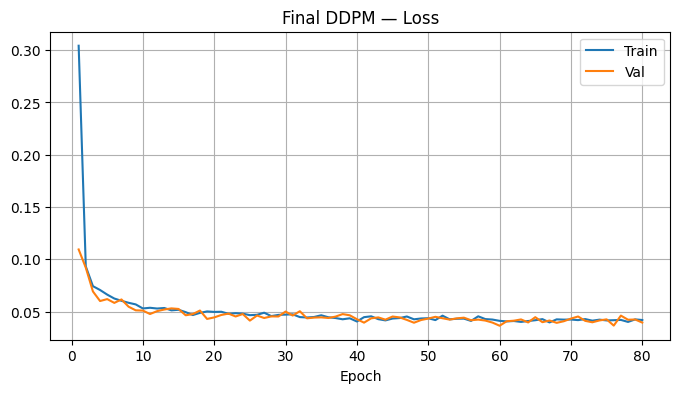

In [14]:
hist_df = pd.DataFrame(final_hist)
plt.figure(figsize=(8,4))
plt.plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
plt.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val')
plt.title('Final DDPM — Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
plt.savefig('../outputs/ddpm_final_loss.png', dpi=150); plt.show()

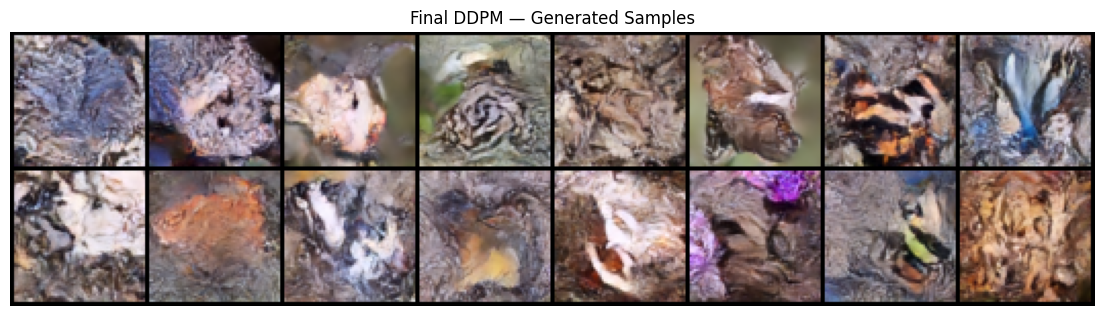

In [15]:
model_final.eval()
preview_labels = torch.arange(min(16, NUM_CLASSES), device=device)
with torch.no_grad():
    samples = diff_final.p_sample_loop(
        model_final, (len(preview_labels),3,64,64),
        class_labels=preview_labels, device=device)
grid = vutils.make_grid(denorm(samples.cpu()), nrow=8, normalize=False)
plt.figure(figsize=(14,4)); plt.axis('off')
plt.title('Final DDPM — Generated Samples')
plt.imshow(grid.permute(1,2,0).numpy())
plt.savefig('../outputs/ddpm_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Generative Evaluation Metrics (SSIM, FID, IS)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.models as tv_models
from scipy import linalg


metric_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Metric device:", metric_device)

# InceptionV3 pré-treinado para FID e Inception Score
inception = tv_models.inception_v3(
    weights=tv_models.Inception_V3_Weights.DEFAULT,
    transform_input=False
).to(metric_device)

inception.eval()


def get_inception_features(imgs_tensor, batch_size=64):
    """
    Extrai features 2048-d do avgpool do InceptionV3.
    imgs_tensor deve estar em [0,1] com shape (N,3,H,W).
    """
    feats_all = []

    def hook(module, inputs, output):
        feats_all.append(output.squeeze(-1).squeeze(-1).detach().cpu())

    handle = inception.avgpool.register_forward_hook(hook)

    with torch.no_grad():
        for i in range(0, len(imgs_tensor), batch_size):
            batch = imgs_tensor[i:i + batch_size].to(metric_device)
            batch = F.interpolate(
                batch,
                size=(299, 299),
                mode="bilinear",
                align_corners=False
            )
            inception(batch)

    handle.remove()

    return torch.cat(feats_all, dim=0).numpy()


def compute_fid(real_feats, fake_feats):
    """
    FID entre dois conjuntos de features numpy com shape (N, 2048).
    Menor é melhor.
    """
    mu1 = real_feats.mean(axis=0)
    mu2 = fake_feats.mean(axis=0)

    sigma1 = np.cov(real_feats, rowvar=False)
    sigma2 = np.cov(fake_feats, rowvar=False)

    diff = mu1 - mu2

    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

    return float(fid)


def compute_is(imgs_tensor, splits=10, batch_size=64):
    """
    Inception Score a partir de imagens em [0,1].
    Maior é melhor.
    """
    logits_list = []

    with torch.no_grad():
        for i in range(0, len(imgs_tensor), batch_size):
            batch = imgs_tensor[i:i + batch_size].to(metric_device)
            batch = F.interpolate(
                batch,
                size=(299, 299),
                mode="bilinear",
                align_corners=False
            )

            logits = inception(batch)
            logits_list.append(logits.detach().cpu())

    logits = torch.cat(logits_list, dim=0)
    pyx = torch.softmax(logits, dim=1).numpy()
    py = pyx.mean(axis=0)

    kl = pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8))
    scores = np.exp(kl.sum(axis=1))

    chunks = np.array_split(scores, splits)

    return (
        float(np.mean([chunk.mean() for chunk in chunks])),
        float(np.std([chunk.mean() for chunk in chunks]))
    )


print("Funções de avaliação definidas com InceptionV3 em:", metric_device)

Metric device: cuda
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\josec/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:01<00:00, 61.8MB/s] 


Funções de avaliação definidas com InceptionV3 em: cuda


In [18]:
# ── Pre-calcular features das imagens REAIS (val set) ────────────────────────
real_imgs_list = []
for imgs, _ in val_ld:
    real_imgs_list.append(denorm(imgs))  # [0,1]
real_imgs_all = torch.cat(real_imgs_list, dim=0)

print("A extrair features das imagens reais...")
real_feats_ddpm = []
for i in range(0, len(real_imgs_all), 64):
    real_feats_ddpm.append(get_inception_features(real_imgs_all[i:i+64]))
real_feats_ddpm = np.concatenate(real_feats_ddpm, axis=0)

# ── Gerar imagens com o modelo final ─────────────────────────────────────────
N_EVAL = 500
model_final.eval()
gen_imgs_eval = []
ssim_scores_ddpm = []

with torch.no_grad():
    done = 0
    for imgs, labels in val_ld:
        if done >= N_EVAL: break
        imgs = imgs.to(device); labels = labels.to(device)
        gen  = diff_final.p_sample_loop(model_final, imgs.shape, class_labels=labels, device=device)
        for r, g in zip(denorm(imgs.cpu()).permute(0,2,3,1).numpy(),
                        denorm(gen.cpu()).permute(0,2,3,1).numpy()):
            ssim_scores_ddpm.append(ssim_metric(r, g, channel_axis=2, data_range=1.0))
        gen_imgs_eval.append(denorm(gen.cpu()))
        done += imgs.size(0)

gen_imgs_eval = torch.cat(gen_imgs_eval, dim=0)[:N_EVAL]

# ── Extrair features e calcular FID/IS ───────────────────────────────────────
print("A extrair features das imagens geradas...")
fake_feats_ddpm = []
for i in range(0, len(gen_imgs_eval), 64):
    fake_feats_ddpm.append(get_inception_features(gen_imgs_eval[i:i+64]))
fake_feats_ddpm = np.concatenate(fake_feats_ddpm, axis=0)

fid_ddpm = compute_fid(real_feats_ddpm, fake_feats_ddpm)
is_ddpm_mean, is_ddpm_std = compute_is(gen_imgs_eval)
mean_ssim_ddpm = float(np.mean(ssim_scores_ddpm))

ddpm_metrics = {
    "ssim":    mean_ssim_ddpm,
    "fid":     fid_ddpm,
    "is_mean": is_ddpm_mean,
    "is_std":  is_ddpm_std,
}

print(f"SSIM : {mean_ssim_ddpm:.4f}  (higher=better)")
print(f"FID  : {fid_ddpm:.2f}    (lower=better; método 2048-d InceptionV3, idêntico ao VAE e GAN)")
print(f"IS   : {is_ddpm_mean:.2f} +/- {is_ddpm_std:.2f}  (higher=better)")


A extrair features das imagens reais...
A extrair features das imagens geradas...
SSIM : 0.0561  (higher=better)
FID  : 204.43    (lower=better; método 2048-d InceptionV3, idêntico ao VAE e GAN)
IS   : 4.56 +/- 0.67  (higher=better)


## 8. Generate Augmented Dataset

In [19]:
IMAGES_PER_CLASS = 75
OUT_DIR = '../outputs/generated_ddpm'
os.makedirs(OUT_DIR, exist_ok=True)
model_final.eval()
total_generated = 0

print(f'Generating {IMAGES_PER_CLASS} images per class ({NUM_CLASSES} classes)...')
for cls_idx, cls_name in tqdm(idx_to_class.items(), desc='Classes'):
    cls_dir = os.path.join(OUT_DIR, cls_name)
    os.makedirs(cls_dir, exist_ok=True)
    generated = 0
    while generated < IMAGES_PER_CLASS:
        n = min(8, IMAGES_PER_CLASS - generated)
        labels = torch.full((n,), cls_idx, device=device, dtype=torch.long)
        with torch.no_grad():
            imgs = diff_final.p_sample_loop(
                model_final, (n,3,64,64), class_labels=labels, device=device)
        imgs_np = (denorm(imgs.cpu()).permute(0,2,3,1).numpy() * 255).astype('uint8')
        for img_arr in imgs_np:
            Image.fromarray(img_arr).save(
                os.path.join(cls_dir, f'gen_{generated:04d}.png'))
            generated += 1
    total_generated += generated

print(f'Done! Total generated: {total_generated}')

Generating 75 images per class (75 classes)...


Classes:   0%|          | 0/75 [00:00<?, ?it/s]

Done! Total generated: 5625


## 9. Retrain Baseline CNN with DDPM Augmentation

In [20]:
# Build augmented training set dataframe
aug_rows = []
for cls_idx, cls_name in idx_to_class.items():
    cls_dir = os.path.join(OUT_DIR, cls_name)
    if not os.path.isdir(cls_dir): continue
    for fname in sorted(os.listdir(cls_dir)):
        if fname.endswith('.png'):
            aug_rows.append({'filename': os.path.join(cls_dir, fname), 'label': cls_name})
aug_df = pd.DataFrame(aug_rows)
print(f'Generated images: {len(aug_df)}')

train_t, val_t = get_transforms()

class AbsPathDataset(data.Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.c2i = class_to_idx
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filename']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.c2i[row['label']], dtype=torch.long)

orig_ds  = ButterflyDataset(df=train_df, img_dir=train_dir, transform=train_t)
gen_ds   = AbsPathDataset(aug_df, class_to_idx, transform=train_t)
combo_ds = data.ConcatDataset([orig_ds, gen_ds])
print(f'Combined dataset: {len(combo_ds)} images')

combo_ld = data.DataLoader(combo_ds, batch_size=32, shuffle=True, num_workers=0)
val_cls_ds = ButterflyDataset(df=val_df, img_dir=train_dir, transform=val_t)
val_cls_ld = data.DataLoader(val_cls_ds, batch_size=32, shuffle=False, num_workers=0)

Generated images: 5625
Combined dataset: 9784 images


In [21]:
def train_classifier(train_loader, val_loader, n_classes, epochs=80, patience=5):
    """Treina o BaselineCNN com os parâmetros do enunciado (batch=32, lr=1e-3, Adam)."""
    clf = BaselineCNN(num_classes=n_classes).to(device)
    opt = optim.Adam(clf.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_f1, no_imp, best_state = 0.0, 0, None
    best_path = "../outputs/models/baseline_cnn_ddpm_aug.pth"
    history = []

    for epoch in range(epochs):
        clf.train()
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            loss = criterion(clf(imgs), lbls)
            loss.backward(); opt.step()

        clf.eval(); all_pred, all_true = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                preds = clf(imgs.to(device)).argmax(1).cpu()
                all_pred.extend(preds.tolist())
                all_true.extend(lbls.tolist())
        val_acc = accuracy_score(all_true, all_pred)
        val_f1  = f1_score(all_true, all_pred, average="weighted", zero_division=0)
        history.append({"epoch": epoch+1, "val_acc": val_acc, "val_f1": val_f1})

        print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f}  F1: {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1; no_imp = 0
            best_state = {k: v.cpu().clone() for k,v in clf.state_dict().items()}
            torch.save(clf.state_dict(), best_path)
            print(f"   Best saved (F1={best_f1:.4f})")
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stopping at epoch {epoch+1}"); break

    clf.load_state_dict(best_state)
    return clf, best_f1, history

print("Training Baseline CNN with DDPM augmentation...")
clf_ddpm, best_f1_ddpm, hist_ddpm = train_classifier(combo_ld, val_cls_ld, NUM_CLASSES)

clf_ddpm.eval(); all_pred, all_true = [], []
with torch.no_grad():
    for imgs, lbls in val_cls_ld:
        preds = clf_ddpm(imgs.to(device)).argmax(1).cpu()
        all_pred.extend(preds.tolist()); all_true.extend(lbls.tolist())
ddpm_acc = accuracy_score(all_true, all_pred)
ddpm_f1  = f1_score(all_true, all_pred, average="weighted", zero_division=0)
print(f"DDPM Aug CNN | val_acc={ddpm_acc:.4f} | val_f1={ddpm_f1:.4f}")


Training Baseline CNN with DDPM augmentation...


Epoch 1/80:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 01 | Val Acc: 0.0298  F1: 0.0024
   Best saved (F1=0.0024)


Epoch 2/80:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 02 | Val Acc: 0.0519  F1: 0.0120
   Best saved (F1=0.0120)


...

Epoch 58 | Val Acc: 0.6038  F1: 0.5908


Epoch 59/80:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 59 | Val Acc: 0.6163  F1: 0.6150


Epoch 60/80:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 60 | Val Acc: 0.6212  F1: 0.6124
Early stopping at epoch 60
DDPM Aug CNN | val_acc=0.6327 | val_f1=0.6279


## 10. Results & Comparison

In [22]:
with open('../outputs/baseline_results.json') as f: base_res = json.load(f)
with open('../outputs/vae_aug_results.json')  as f: vae_res  = json.load(f)

ddpm_results = {
    'model': 'Baseline CNN + DDPM aug',
    'val_accuracy': ddpm_acc,
    'val_f1_weighted': ddpm_f1,
    'ddpm_config': best_cfg_params,
    'generative_metrics': ddpm_metrics,
}
with open('../outputs/ddpm_aug_results.json','w') as f:
    json.dump(ddpm_results, f, indent=2)

comparison = pd.DataFrame([
    {'Model': 'Baseline CNN (no aug)',
     'Val Accuracy': round(base_res['val_accuracy'],4),
     'Val F1':       round(base_res['val_f1_weighted'],4),
     'SSIM': '-', 'FID': '-', 'IS': '-'},
    {'Model': 'Baseline CNN + VAE aug',
     'Val Accuracy': round(vae_res['val_accuracy'],4),
     'Val F1':       round(vae_res['val_f1_weighted'],4),
     'SSIM': f"{vae_res['generative_metrics']['ssim']:.4f}",
     'FID':  f"{vae_res['generative_metrics']['fid']:.4f}",
     'IS':   f"{vae_res['generative_metrics']['is_mean']:.4f}"},
    {'Model': 'Baseline CNN + DDPM aug',
     'Val Accuracy': round(ddpm_acc,4),
     'Val F1':       round(ddpm_f1,4),
     'SSIM': f"{ddpm_metrics['ssim']:.4f}",
     'FID':  f"{ddpm_metrics['fid']:.4f}",
     'IS':   f"{ddpm_metrics['is_mean']:.4f}"},
])
print(comparison.to_string(index=False))

                  Model  Val Accuracy  Val F1   SSIM      FID     IS
  Baseline CNN (no aug)        0.4365  0.4022      -        -      -
 Baseline CNN + VAE aug        0.5067  0.4904 0.4810   3.4150 2.2123
Baseline CNN + DDPM aug        0.6327  0.6279 0.0561 204.4268 4.5554


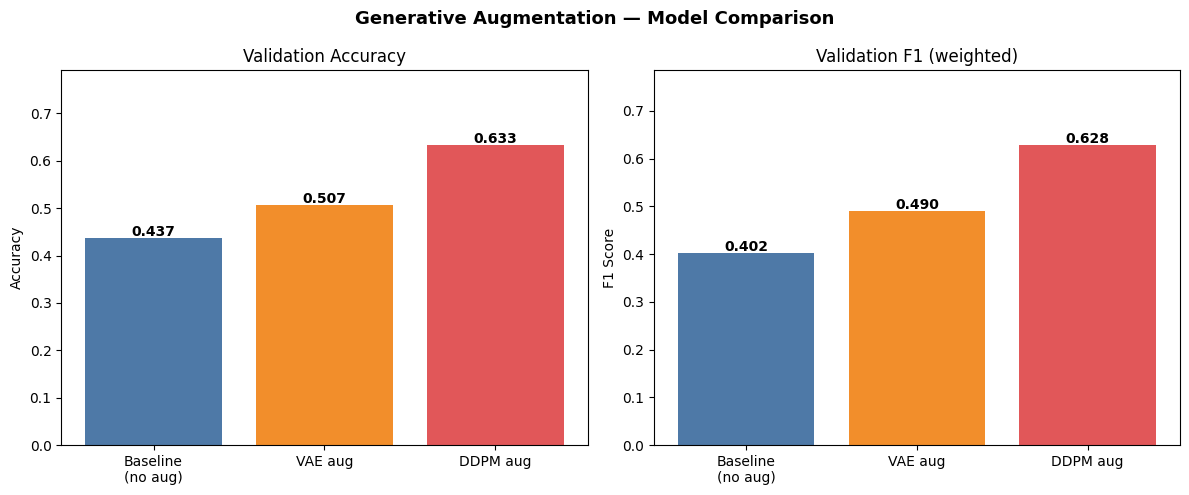


Baseline accuracy : 0.4365
VAE aug accuracy  : 0.5067  (Delta=+0.0702)
DDPM aug accuracy : 0.6327  (Delta=+0.1962)


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
model_names = ['Baseline\n(no aug)', 'VAE aug', 'DDPM aug']
accs = [base_res['val_accuracy'], vae_res['val_accuracy'], ddpm_acc]
f1s  = [base_res['val_f1_weighted'], vae_res['val_f1_weighted'], ddpm_f1]
colors = ['#4e79a7', '#f28e2b', '#e15759']

ax1.bar(model_names, accs, color=colors)
ax1.set_title('Validation Accuracy'); ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, max(accs)*1.25)
for i,v in enumerate(accs): ax1.text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold')

ax2.bar(model_names, f1s, color=colors)
ax2.set_title('Validation F1 (weighted)'); ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, max(f1s)*1.25)
for i,v in enumerate(f1s): ax2.text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Generative Augmentation — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ddpm_comparison.png', dpi=150); plt.show()

print(f"\nBaseline accuracy : {base_res['val_accuracy']:.4f}")
print(f"VAE aug accuracy  : {vae_res['val_accuracy']:.4f}  (Delta={vae_res['val_accuracy']-base_res['val_accuracy']:+.4f})")
print(f"DDPM aug accuracy : {ddpm_acc:.4f}  (Delta={ddpm_acc-base_res['val_accuracy']:+.4f})")

## 11. Kaggle Submission


In [24]:
# ── Submission Kaggle — DDPM-Augmented CNN ────────────────────────────────────
# Carregar o melhor modelo
best_path_ddpm = "../outputs/models/baseline_cnn_ddpm_aug.pth"
clf_ddpm.load_state_dict(torch.load(best_path_ddpm, map_location=device))
clf_ddpm.eval()

# Dataset de teste (sem labels)
test_dir = os.path.join(os.path.dirname(train_dir), "test")
test_files = sorted(os.listdir(test_dir))

_, val_tf_sub = get_transforms()
idx_to_class_sub = {v: k for k, v in class_to_idx.items()}

all_filenames, all_labels = [], []
with torch.no_grad():
    for fname in tqdm(test_files, desc="Inferência no teste"):
        img = Image.open(os.path.join(test_dir, fname)).convert("RGB")
        img_t = val_tf_sub(img).unsqueeze(0).to(device)
        pred  = clf_ddpm(img_t).argmax(1).item()
        all_filenames.append(fname)
        all_labels.append(idx_to_class_sub[pred])

submission_df = pd.DataFrame({"filename": all_filenames, "label": all_labels})
os.makedirs("../outputs/submissions", exist_ok=True)
submission_path = "../outputs/submissions/submission_ddpm_augmented.csv"
submission_df.to_csv(submission_path, index=False)
print(f"Submissão guardada: {submission_path}")
print(f"   {len(submission_df)} linhas | {submission_df["label"].nunique()} classes distintas")
submission_df.head(5)


Inferência no teste:   0%|          | 0/1300 [00:00<?, ?it/s]

Submissão guardada: ../outputs/submissions/submission_ddpm_augmented.csv
   1300 linhas | 74 classes distintas


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,MALACHITE
